# LF 04 · Luminosity function of the Virgo core

r-band luminosity function of the NGVS Virgo core sample of Ferrarese et al. (2020), corrected for photometric incompleteness with their completeness table, and fitted with a Schechter function by MCMC (emcee).

**Inputs**
- `DATA/Ferrarese2020correctionFactor.csv` – completeness (%) vs. M_r from Ferrarese et al. (2020)
- `DATA/Virgo/Virgo_core_mastercat.csv` – Virgo core catalog from `DATA/Virgo/01_kcorrgal.py` (not included)

**Output**
- `Virgo_LF.csv` – binned, corrected LF used by `06_multi_cluster_LF_comparison.ipynb`

Note: the NGVS core region covers about 90′ around M87; the volume is a cylinder of radius 90′ and depth 3 × radius at z = 0.003.

In [1]:
# ============================================================================
# Setup
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import astropy.units as u
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',

    # Ticks: inwards, on all four sides, with minor ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,

    # Axes and lines
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

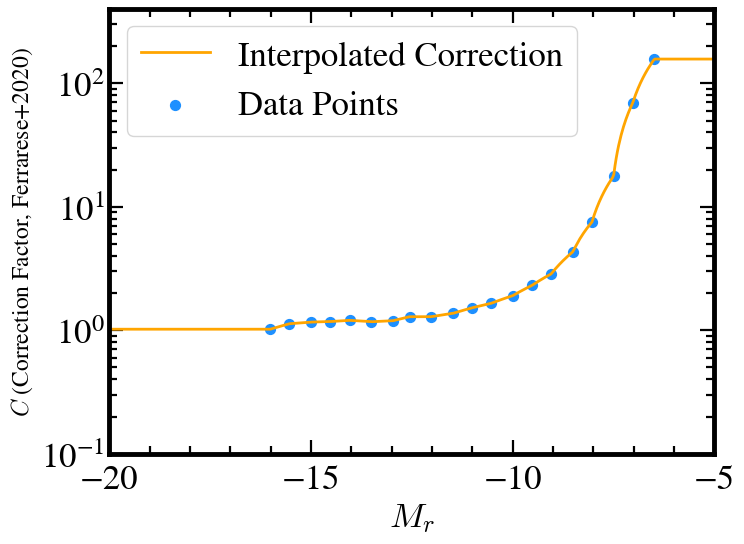

In [2]:
Z_CLID = 0.003      # Virgo (M87) redshift

# Photometric completeness of Ferrarese et al. (2020) -> correction factor 100 / completeness(%)
cordf = pd.read_csv('../../DATA/Ferrarese2020correctionFactor.csv')
cordf['CorrectionFactor'] = 100 / cordf['Completeness']

def C_photcor(mag):
    """
    Photometric incompleteness correction factor at absolute magnitude `mag`,
    linearly interpolated in the Ferrarese et al. (2020) table and clamped at both ends.
    """
    mag = float(mag)
    sorted_df = cordf.sort_values('M_r').reset_index(drop=True)
    x_min, x_max = sorted_df['M_r'].iloc[0], sorted_df['M_r'].iloc[-1]

    if mag <= x_min:
        return sorted_df['CorrectionFactor'].iloc[0]
    if mag >= x_max:
        return sorted_df['CorrectionFactor'].iloc[-1]

    row_match = sorted_df[sorted_df['M_r'] == mag]
    if not row_match.empty:
        return row_match['CorrectionFactor'].values[0]

    lower = sorted_df[sorted_df['M_r'] < mag].iloc[-1]
    upper = sorted_df[sorted_df['M_r'] > mag].iloc[0]
    x0, y0 = lower['M_r'], lower['CorrectionFactor']
    x1, y1 = upper['M_r'], upper['CorrectionFactor']
    return y0 + (y1 - y0) * (mag - x0) / (x1 - x0)

# Show the interpolated curve against the table values
x_range = np.linspace(-20, -5, 500)
y_interp = [C_photcor(x) for x in x_range]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_range, y_interp, color='orange', label='Interpolated Correction')
ax.scatter(cordf['M_r'], cordf['CorrectionFactor'], color='dodgerblue', s=50, label='Data Points')
ax.set_xlabel('$M_r$')
ax.set_ylabel(r'$C$ (Correction Factor, Ferrarese+2020)', fontsize=17)
ax.set_xlim([-20, -5])
ax.set_ylim([0.1, 400])
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
import emcee

# Virgo core catalog; Class 2 = background/uncertain objects are excluded
df = pd.read_csv('../../DATA/Virgo/Virgo_core_mastercat.csv')
df_plot = df[df['Class'] != 2].copy()
df_plot['weight'] = df_plot['p_mag_r_absmag'].apply(C_photcor)

# ---- Schechter function in magnitudes and the log-posterior ----
def schechter_1D_LF(M, phi_0, M_star, alpha):
    """Schechter luminosity function in magnitude space."""
    x = 10 ** (0.4 * (M_star - M))
    return phi_0 * x ** (1 + alpha) * np.exp(-x)

def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_LF(M, phi_0, M_star, alpha)
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 100 and -32 < M_star < -14 and -3 < alpha < 0:     # flat priors
        return 0.0
    return -np.inf

def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

# ---- Volume: cylinder of radius 90 arcmin and depth 3 x radius, in h^-3 Mpc^3 ----
h = cosmo.H0.value / 100.0
z = Z_CLID
comoving_dist = cosmo.comoving_distance(z)
theta_arcmin = 90 * u.arcmin
transverse_dist = comoving_dist * (theta_arcmin.to(u.rad) / u.rad)
comoving_volume = 3 * np.pi * transverse_dist**3
volume_h3 = comoving_volume.value * h**3

# ---- Weighted counts per 0.5-mag bin -> number density ----
bin_width = 0.5
bin_edges = np.arange(-24, -12 + bin_width, bin_width)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

weights = df_plot['weight']
hist_corr, _ = np.histogram(df_plot['p_mag_r_absmag'], bins=bin_edges, weights=weights)
variance_corr, _ = np.histogram(df_plot['p_mag_r_absmag'], bins=bin_edges, weights=weights**2)
yerr_corr = np.sqrt(np.maximum(variance_corr, 0))

hist_corr_density = hist_corr / (bin_width * volume_h3)
yerr_corr_density = yerr_corr / (bin_width * volume_h3)

# Fit range
fit_range = (-24, -13)
in_fit = (
    (bin_centers > fit_range[0]) &
    (bin_centers < fit_range[1]) &
    (hist_corr_density > 0)
)
x_fit = bin_centers[in_fit]
y_fit = hist_corr_density[in_fit]
yerr_fit = yerr_corr_density[in_fit]

# ---- MCMC fit ----
nwalkers = 500
nsteps = 5000
ndim = 3
initial = np.array([0.5, -21.35, -1.24])       # phi_0, M*, alpha
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x_fit, y_fit, yerr_fit))
print(f"Running MCMC with {nwalkers} walkers for {nsteps} steps...")
sampler.run_mcmc(pos, nsteps, progress=True)

# Medians and 16-84 percentile errors
samples = sampler.get_chain(discard=1000, thin=15, flat=True)
phi0_lo, phi0_med, phi0_hi = np.percentile(samples[:, 0], [16, 50, 84])
mstar_lo, mstar_med, mstar_hi = np.percentile(samples[:, 1], [16, 50, 84])
alpha_lo, alpha_med, alpha_hi = np.percentile(samples[:, 2], [16, 50, 84])

phi0_err = [phi0_med - phi0_lo, phi0_hi - phi0_med]
M_star_err = [mstar_med - mstar_lo, mstar_hi - mstar_med]
alpha_err = [alpha_med - alpha_lo, alpha_hi - alpha_med]

Running MCMC with 500 walkers for 5000 steps...


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 16/5000 [00:00<00:32, 152.24it/s]

  1%|          | 32/5000 [00:00<00:31, 156.35it/s]

  1%|          | 50/5000 [00:00<00:29, 165.86it/s]

...

 99%|█████████▉| 4941/5000 [00:28<00:00, 177.68it/s]

 99%|█████████▉| 4959/5000 [00:28<00:00, 177.14it/s]

100%|█████████▉| 4977/5000 [00:28<00:00, 176.36it/s]

100%|█████████▉| 4995/5000 [00:28<00:00, 175.62it/s]

100%|██████████| 5000/5000 [00:28<00:00, 175.16it/s]

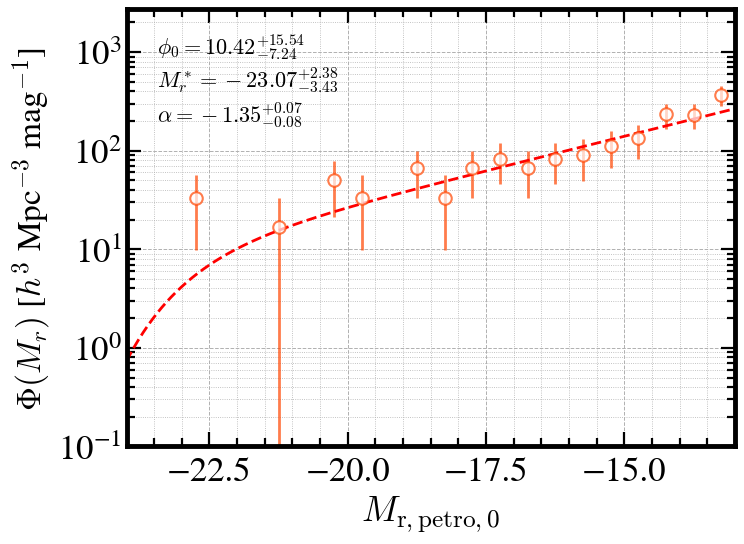

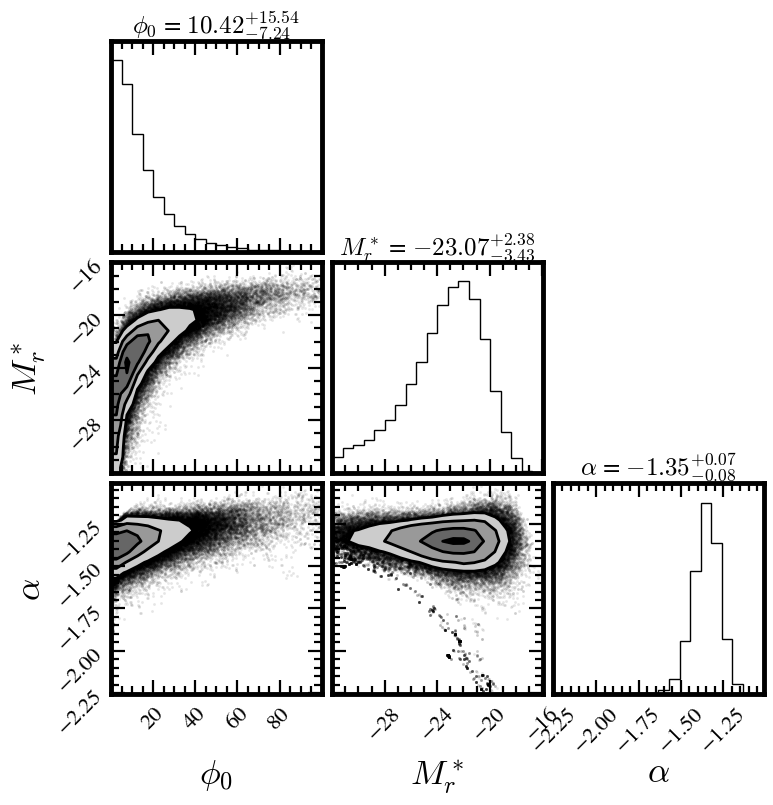

In [4]:
import corner

# ---- LF with the best-fit Schechter function ----
fig, ax = plt.subplots(figsize=(8, 6))

# Shade the range outside the fit
ax.axvspan(-24, fit_range[0], color='gray', alpha=0.7)
ax.axvspan(fit_range[1], -13, color='gray', alpha=0.7)

mask_positive = hist_corr_density > 0
ax.errorbar(
    bin_centers[mask_positive], hist_corr_density[mask_positive],
    yerr=yerr_corr_density[mask_positive],
    fmt='o', color='orangered', ecolor='orangered',
    markerfacecolor='white', markeredgewidth=1.5,
    capsize=0, alpha=0.7, markersize=9
)

x_model = np.linspace(-24, -12, 1000)
y_model = schechter_1D_LF(x_model, phi0_med, mstar_med, alpha_med)
ax.plot(x_model, y_model, color='red', linestyle='--', lw=2.0)

ax.set_yscale('log')
ax.set_xlim(-24, -13)
ax.set_ylim(1e-1, hist_corr_density.max() * 5)
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$\Phi(M_r)$ [$h^3$ Mpc$^{-3}$ mag$^{-1}$]', fontsize=24)
ax.grid(True, which='major', linestyle='--', linewidth=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.6)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

annot = (
    r"$\phi_0 = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(phi0_med, phi0_err[1], phi0_err[0]) + "\n" +
    r"$M^*_r = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(mstar_med, M_star_err[1], M_star_err[0]) + "\n" +
    r"$\alpha = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(alpha_med, alpha_err[1], alpha_err[0])
)
ax.text(
    0.05, 0.95, annot, transform=ax.transAxes,
    fontsize=16, verticalalignment='top', horizontalalignment='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8)
)

plt.tight_layout()
plt.show()

# ---- Save the binned LF for the multi-cluster comparison ----
spec_comp_limit = 0          # no completeness cut for Virgo: keep every fitted bin
save_mask = x_fit < spec_comp_limit
df_save = pd.DataFrame({
    'M_r': x_fit[save_mask],
    'Phi': y_fit[save_mask],
    'Phi_err': yerr_fit[save_mask]
})
df_save.to_csv('Virgo_LF.csv', index=False)

# ---- Posterior corner plot ----
labels = [r"$\phi_0$", r"$M^*_r$", r"$\alpha$"]
fig = corner.corner(
    samples,
    labels=labels,
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 18},
    plot_contours=True,
    fill_contours=True,
    fig=plt.figure(figsize=(8, 8))
)
for corner_ax in fig.get_axes():
    corner_ax.tick_params(axis='both', labelsize=16)
plt.show()